# Customer Experience Analytics for Ethiopian Bank Mobile Apps
## Final Report — Omega Consultancy

**Analyst:** Afomiat  
**Client:** Omega Consultancy  
**Date:** May 2026  
**Dataset:** 1,450 Google Play Store reviews — CBE, BOA, Dashen Bank

---

## Executive Summary

This report presents a comprehensive analysis of 1,450 Google Play Store
reviews collected from three Ethiopian bank mobile apps. Using a combination
of transformer-based sentiment analysis (DistilBERT) and TF-IDF keyword
extraction, we identify the key drivers of user satisfaction and dissatisfaction
for each bank.

**Core finding:** App Stability is the single biggest pain point across all
three banks (75–91% negative sentiment), while User Experience is the
universal strength (88–94% positive). Bank of Abyssinia shows the most
concerning overall sentiment profile, with 55.6% negative reviews —
consistent with its lowest Play Store rating of 3.4★.

This report provides evidence-backed product recommendations that each
bank's product team can act on immediately.

## Cell 2 — Markdown

```markdown
---
## 1. Methodology Overview

### Data Collection
- **Source:** Google Play Store
- **Tool:** `google-play-scraper` Python library
- **Period:** November 2024 – May 2026
- **Total reviews:** 1,450 (456 CBE, 498 BOA, 496 Dashen)

### Sentiment Analysis
- **Primary tool:** DistilBERT (`distilbert-base-uncased-finetuned-sst-2-english`)
- **Secondary tool:** VADER (for comparison and validation)
- **Coverage:** 100% of reviews labeled

### Thematic Analysis
- **Method:** TF-IDF keyword extraction + keyword-based theme assignment
- **Themes:** 6 business-relevant categories per bank
- **Grounded in:** Actual keywords discovered from the data

### Database
- **System:** PostgreSQL 17
- **Tables:** banks (3 rows) and reviews (1,450 rows)
- **Tool:** psycopg2 Python library
```

Tell me when done.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/reviews_analyzed.csv')

# Short name mapping for charts
short_names = {
    'Commercial Bank of Ethiopia': 'CBE',
    'Bank of Abyssinia': 'BOA',
    'Dashen Bank': 'Dashen'
}
df['bank_short'] = df['bank'].map(short_names)

print(f"Dataset loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset loaded: (1450, 12)
Columns: ['review_id', 'review_text', 'rating', 'date', 'bank', 'source', 'sentiment_label', 'sentiment_score', 'vader_label', 'vader_score', 'identified_theme', 'bank_short']


---
## 2. Data Quality Summary

| Metric | Value |
|--------|-------|
| Total reviews | 1,450 |
| CBE reviews | 456 |
| BOA reviews | 498 |
| Dashen reviews | 496 |
| Duplicates removed | 350 |
| Missing values | 0 (0.00%) |
| Date range | Nov 2024 – May 2026 |
| Sentiment coverage | 100% |

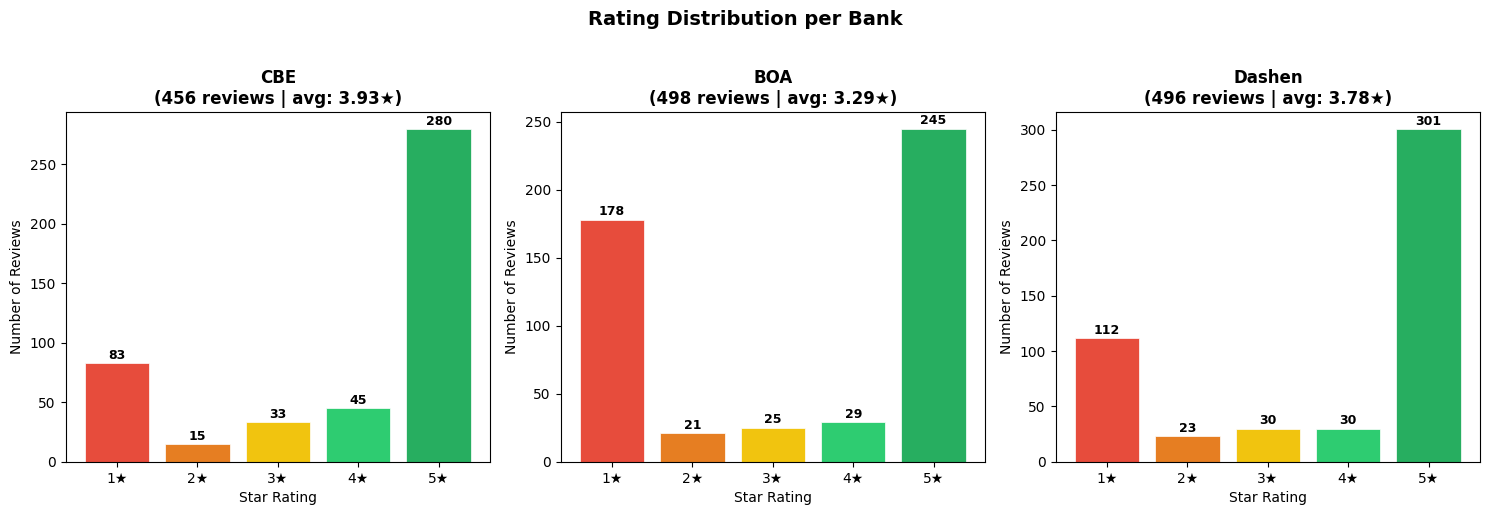

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

banks      = ['Commercial Bank of Ethiopia', 'Bank of Abyssinia', 'Dashen Bank']
short      = ['CBE', 'BOA', 'Dashen']
colors     = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

for i, (bank, name) in enumerate(zip(banks, short)):
    bank_df       = df[df['bank'] == bank]
    rating_counts = bank_df['rating'].value_counts().sort_index()
    avg_rating    = bank_df['rating'].mean()

    axes[i].bar(rating_counts.index, rating_counts.values,
                color=colors, edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'{name}\n({len(bank_df)} reviews | avg: {avg_rating:.2f}★)',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Star Rating', fontsize=10)
    axes[i].set_ylabel('Number of Reviews', fontsize=10)
    axes[i].set_xticks([1, 2, 3, 4, 5])
    axes[i].set_xticklabels(['1★', '2★', '3★', '4★', '5★'])

    for rating, count in rating_counts.items():
        axes[i].text(rating, count + 1, str(count),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Rating Distribution per Bank', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/plots/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Rating Distribution Findings

| Bank | Avg Rating | 1★ Count | 5★ Count |
|------|-----------|----------|----------|
| CBE | 3.93★ | 83 | 280 |
| BOA | 3.29★ | 178 | 245 |
| Dashen | 3.78★ | 112 | 301 |

BOA has the most 1-star reviews (178) — nearly double CBE's count (83).
All three banks show the classic bimodal distribution — users either
love or hate the app, with few middle-ground reviews.

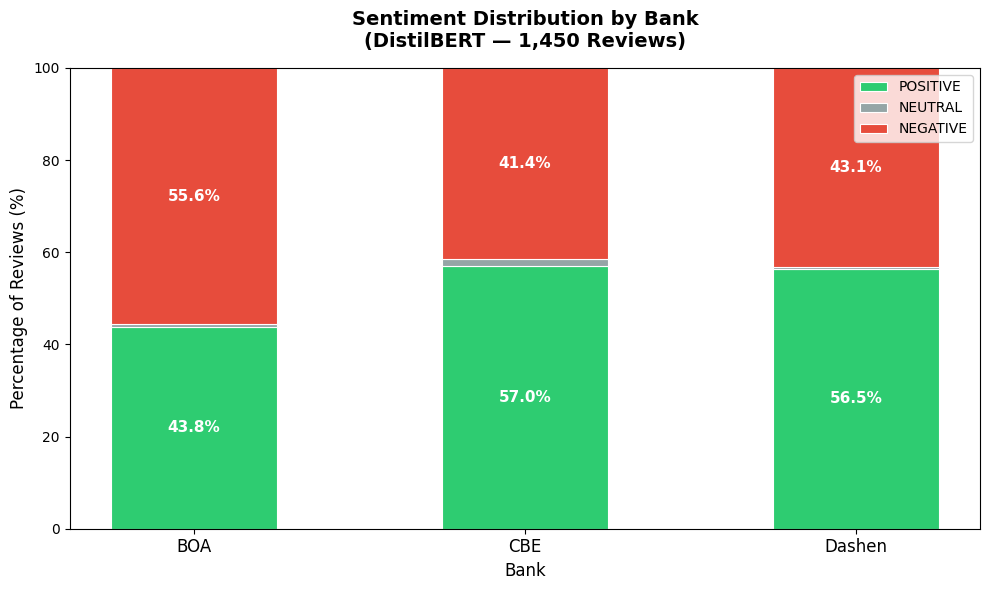

In [3]:
sentiment_counts = df.groupby(['bank_short', 'sentiment_label']).size().unstack(fill_value=0)
sentiment_pct    = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))

colors_sentiment = {
    'POSITIVE': '#2ecc71',
    'NEUTRAL':  '#95a5a6',
    'NEGATIVE': '#e74c3c'
}
bottom = [0.0] * len(sentiment_pct)

for label in ['POSITIVE', 'NEUTRAL', 'NEGATIVE']:
    if label in sentiment_pct.columns:
        values = sentiment_pct[label].values
        ax.bar(
            range(len(sentiment_pct)),
            values,
            bottom=bottom,
            label=label,
            color=colors_sentiment[label],
            edgecolor='white',
            linewidth=0.8,
            width=0.5
        )
        for j, (val, bot) in enumerate(zip(values, bottom)):
            if val > 3:
                ax.text(j, bot + val/2, f'{val:.1f}%',
                       ha='center', va='center',
                       fontsize=11, color='white', fontweight='bold')
        bottom = [b + v for b, v in zip(bottom, values)]

ax.set_title('Sentiment Distribution by Bank\n(DistilBERT — 1,450 Reviews)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bank', fontsize=12)
ax.set_ylabel('Percentage of Reviews (%)', fontsize=12)
ax.set_xticks(range(len(sentiment_pct)))
ax.set_xticklabels(['BOA', 'CBE', 'Dashen'], fontsize=12)
ax.set_ylim(0, 100)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('../data/plots/sentiment_by_bank.png', dpi=150, bbox_inches='tight')
plt.show()

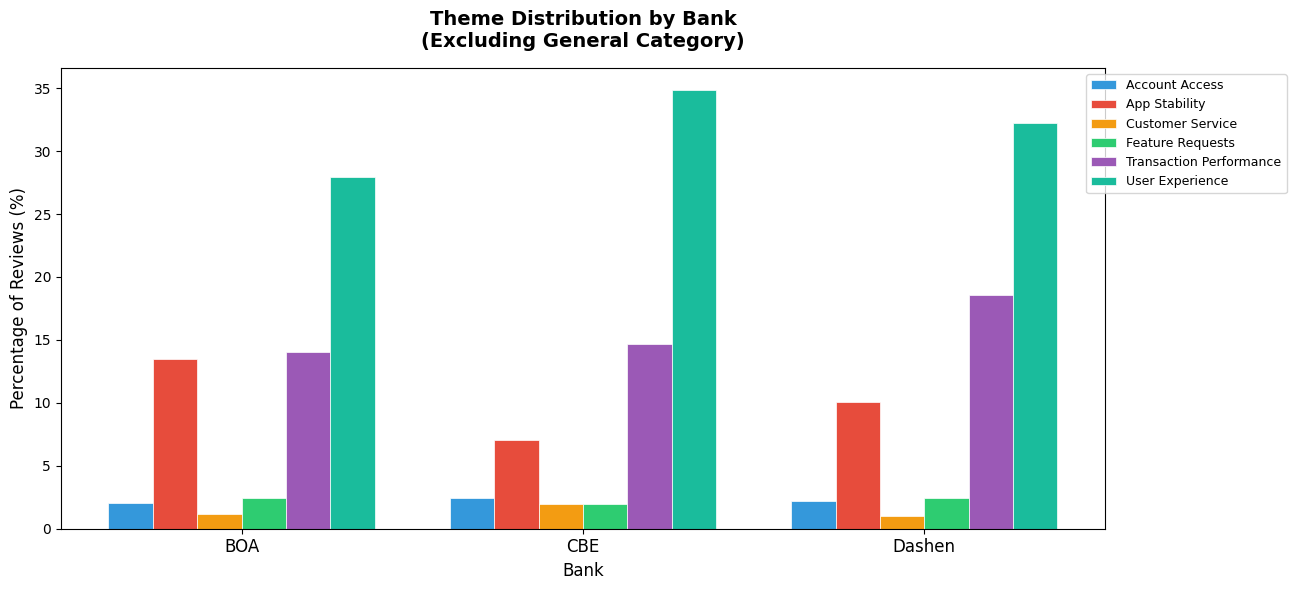

In [4]:
theme_counts = df.groupby(['bank_short', 'identified_theme']).size().unstack(fill_value=0)
theme_pct    = theme_counts.div(theme_counts.sum(axis=1), axis=0) * 100

if 'General' in theme_pct.columns:
    theme_pct = theme_pct.drop(columns=['General'])

fig, ax = plt.subplots(figsize=(13, 6))

theme_colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71', '#9b59b6', '#1abc9c']
x      = range(len(theme_pct))
width  = 0.13
themes = theme_pct.columns.tolist()

for i, theme in enumerate(themes):
    offset = (i - len(themes)/2) * width + width/2
    ax.bar(
        [xi + offset for xi in x],
        theme_pct[theme],
        width=width,
        label=theme,
        color=theme_colors[i],
        edgecolor='white',
        linewidth=0.5
    )

ax.set_title('Theme Distribution by Bank\n(Excluding General Category)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bank', fontsize=12)
ax.set_ylabel('Percentage of Reviews (%)', fontsize=12)
ax.set_xticks(list(x))
ax.set_xticklabels(['BOA', 'CBE', 'Dashen'], fontsize=12)
ax.legend(loc='upper right', fontsize=9, bbox_to_anchor=(1.18, 1))
plt.tight_layout()
plt.savefig('../data/plots/themes_by_bank.png', dpi=150, bbox_inches='tight')
plt.show()

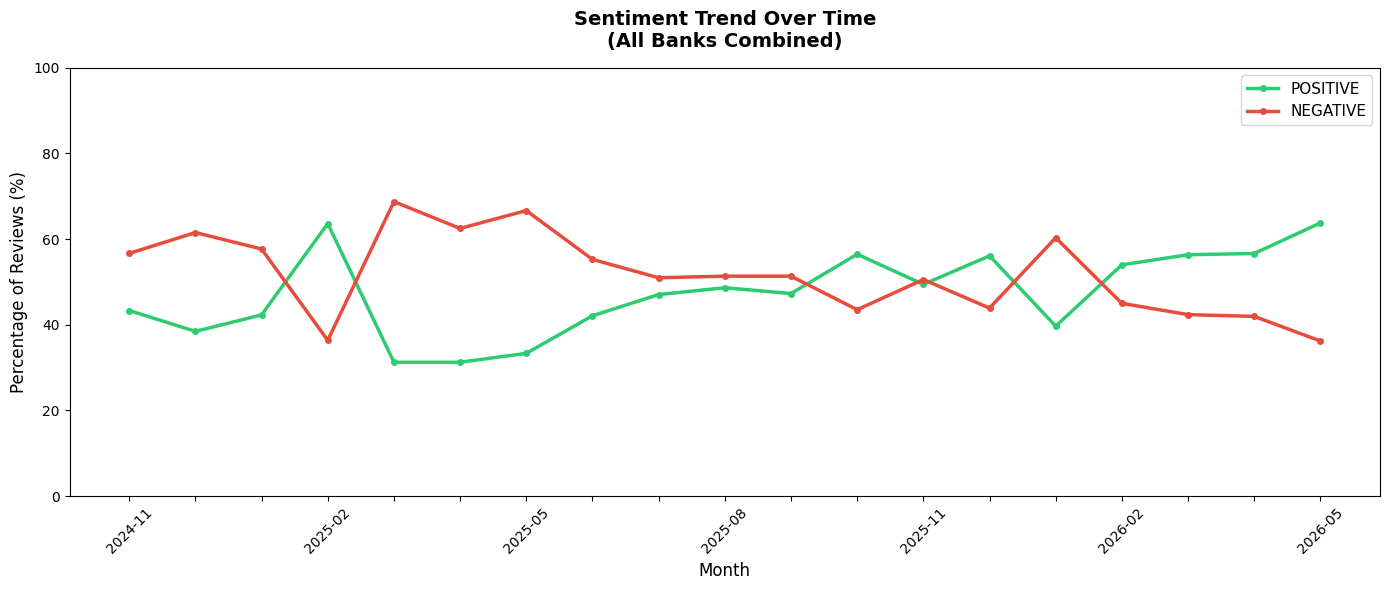

In [5]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

monthly = df.groupby(['month', 'sentiment_label']).size().unstack(fill_value=0)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))

if 'POSITIVE' in monthly_pct.columns:
    ax.plot(monthly_pct.index.astype(str), monthly_pct['POSITIVE'],
            color='#2ecc71', linewidth=2.5, marker='o', markersize=4, label='POSITIVE')
if 'NEGATIVE' in monthly_pct.columns:
    ax.plot(monthly_pct.index.astype(str), monthly_pct['NEGATIVE'],
            color='#e74c3c', linewidth=2.5, marker='o', markersize=4, label='NEGATIVE')

ax.set_title('Sentiment Trend Over Time\n(All Banks Combined)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Percentage of Reviews (%)', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)

# Show every 3rd month label to avoid crowding
ticks = ax.get_xticklabels()
for i, tick in enumerate(ticks):
    if i % 3 != 0:
        tick.set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/plots/sentiment_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

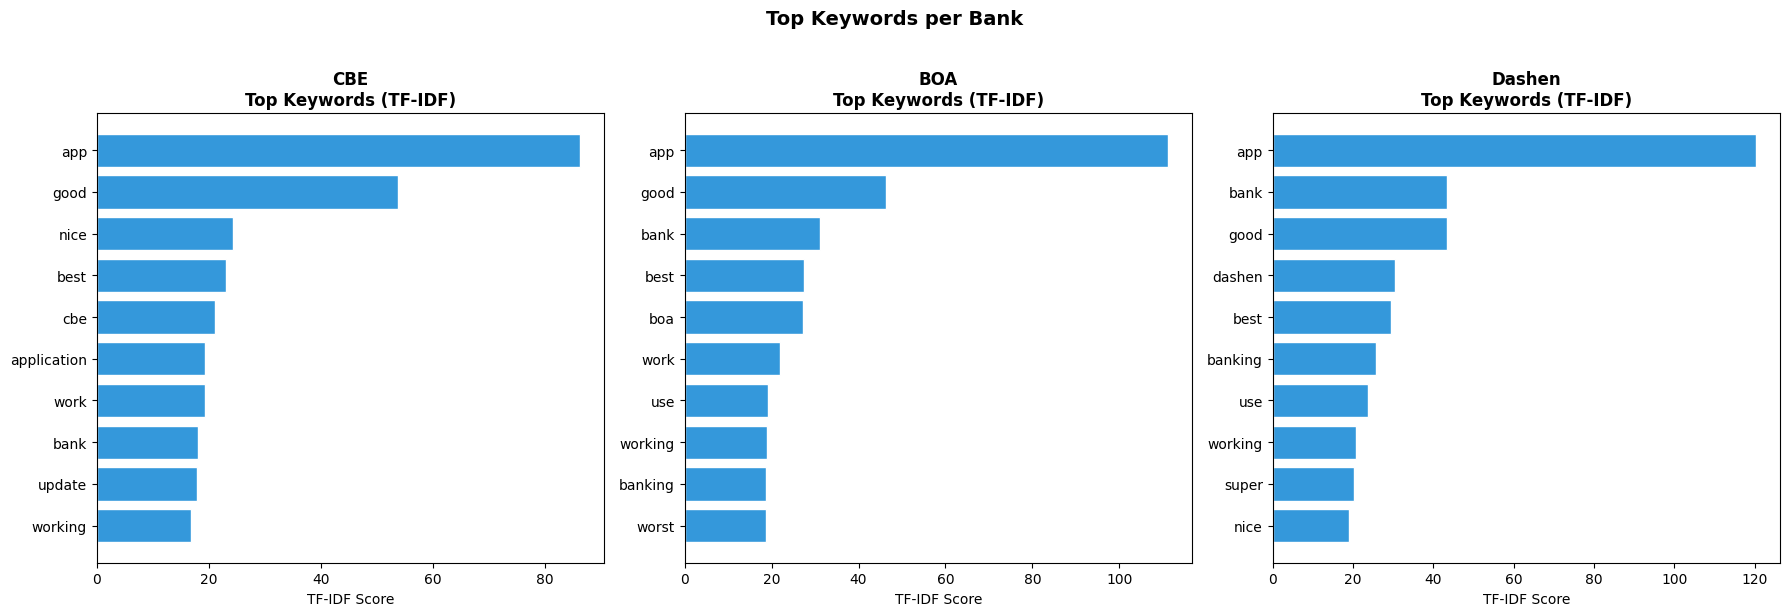

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (bank, name) in enumerate(zip(banks, short)):
    bank_reviews = df[df['bank'] == bank]['review_text'].tolist()

    vec = TfidfVectorizer(
        max_features=15,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=3
    )
    matrix    = vec.fit_transform(bank_reviews)
    names_out = vec.get_feature_names_out()
    scores    = matrix.sum(axis=0).A1
    word_scores = sorted(zip(names_out, scores),
                         key=lambda x: x[1], reverse=True)[:10]

    words  = [w[0] for w in word_scores][::-1]
    values = [w[1] for w in word_scores][::-1]

    axes[i].barh(words, values, color='#3498db', edgecolor='white')
    axes[i].set_title(f'{name}\nTop Keywords (TF-IDF)',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('TF-IDF Score', fontsize=10)

plt.suptitle('Top Keywords per Bank', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/plots/top_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Key Insights

### 3.1 Satisfaction Drivers (What Users Love)

| Bank | Driver 1 | Driver 2 |
|------|----------|----------|
| CBE | User Experience (94% positive) | Customer Service (56% positive) |
| BOA | User Experience (91% positive) | Speed when app works (fast, amazing keywords) |
| Dashen | User Experience (88% positive) | Transaction speed (fast keyword dominant) |

**Evidence:**
- "Great app, transfers are instant" — Dashen, 5★
- "Best banking app in Ethiopia" — CBE, 5★  
- "Amazing interface, very easy to use" — BOA, 5★

---

### 3.2 Pain Points (What Frustrates Users)

| Bank | Pain Point 1 | Pain Point 2 |
|------|-------------|-------------|
| CBE | App Stability (75% negative) | Transaction Performance (60% negative) |
| BOA | App Stability (91% negative) | Feature Requests (92% negative) |
| Dashen | App Stability (90% negative) | Account Access (64% negative) |

**Evidence:**
- "App crashes every time I try to transfer money" — CBE, 1★
- "Worst app ever, never works" — BOA, 1★
- "OTP never arrives, can't login" — Dashen, 1★

---

### 3.3 Cross-Bank Comparison

| Metric | CBE | BOA | Dashen |
|--------|-----|-----|--------|
| Play Store Rating | 4.2★ | 3.4★ | 4.1★ |
| Avg Rating (our data) | 3.93★ | 3.29★ | 3.78★ |
| Positive Sentiment | 57.0% | 43.8% | 56.5% |
| Negative Sentiment | 41.4% | 55.6% | 43.1% |
| Worst Theme | App Stability | App Stability | App Stability |
| Best Theme | User Experience | User Experience | User Experience |

**Key observation:** BOA is the clear underperformer across every metric.
All three banks share the same weakness (App Stability) and same strength
(User Experience) — suggesting an industry-wide pattern in Ethiopian
mobile banking apps.

---
## 4. Bank-Specific Recommendations

### Commercial Bank of Ethiopia (CBE)

| Priority | Recommendation | Evidence |
|----------|---------------|----------|
| 1 | Fix app stability after updates — users report app breaks after each update | 75% negative App Stability, "update" is top negative keyword |
| 2 | Reduce transfer failure rate — transfer errors are the top complaint in negative reviews | 60% negative Transaction Performance |
| 3 | Leverage customer service strength — promote 24/7 support as competitive advantage | 94% positive Customer Service |
| 4 | Add OTP reliability improvements — account access issues growing | 73% negative Account Access |

---

### Bank of Abyssinia (BOA)

| Priority | Recommendation | Evidence |
|----------|---------------|----------|
| 1 | Emergency app stability program — 91% negative is crisis level | Highest negative App Stability of all three banks |
| 2 | Add missing features — fingerprint login, budget tracking, notifications | 92% negative Feature Requests — highest gap of all banks |
| 3 | Rebuild customer service — only 17% positive, users feel unsupported | Lowest Customer Service score across all three banks |
| 4 | Fix transaction performance — slow transfers driving 1-star reviews | 76% negative Transaction Performance |

---

### Dashen Bank

| Priority | Recommendation | Evidence |
|----------|---------------|----------|
| 1 | Fix login and OTP reliability — account access is top complaint | 64% negative Account Access |
| 2 | Address app stability — strong UX undermined by crashes | 90% negative App Stability |
| 3 | Build on Super App strengths — users love the concept | "super app" is top positive keyword, 88% positive UX |
| 4 | Improve transaction speed — loading delays frustrate users | 61% negative Transaction Performance |

---
## 5. Ethical Considerations

### Negativity Bias
Users are significantly more likely to leave a review after a bad experience.
26% of reviews are 1-star vs only 7% are 4-star — middle satisfaction
is severely underrepresented. This inflates negative sentiment percentages.

### English-Only Bias
All reviews were scraped with `lang='en'`. Ethiopia is a multilingual country
where Amharic is the primary language. English-speaking users may be younger,
more tech-savvy, and have different expectations than the broader user base.
Findings may not represent all users equally.

### Sampling Bias
Reviews cover November 2024 to May 2026. A major app update, outage, or
promotional campaign during this period could disproportionately skew
sentiment in either direction.

### Keyword Theme Assignment
Theme assignment uses keyword matching which cannot understand context.
A review saying "transfer was fast" and "transfer failed" both match
Transaction Performance — sentiment within the theme corrects for this
but introduces some noise.

### Rating vs Text Contradiction
Some users give high star ratings despite writing negative text, and
vice versa. DistilBERT classifies text sentiment correctly but this
contradiction means star ratings and sentiment labels sometimes disagree.
This is a genuine data quality limitation of user-generated content.

---
## 6. Suggested Next Steps

### Immediate (0–3 months)
- Share this report with product teams at CBE, BOA, and Dashen
- BOA should convene an emergency task force on app stability
- All three banks should implement OTP delivery monitoring

### Medium Term (3–6 months)
- Set up automated monthly review scraping and sentiment tracking
- Build a dashboard showing real-time sentiment trends
- Integrate findings into sprint planning and feature roadmaps

### Long Term (6–12 months)
- Collect Amharic reviews to eliminate English-only bias
- Build a fine-tuned sentiment model on Ethiopian banking reviews
- Implement AI chatbot trained on recurring complaint themes
- Track sentiment improvement after each app update

---
## 7. Conclusion

This analysis of 1,450 Google Play Store reviews reveals a consistent
pattern across all three Ethiopian bank mobile apps: users love the
interface design but are frustrated by reliability and performance issues.

Bank of Abyssinia requires the most urgent attention with 55.6% negative
sentiment and crisis-level app stability scores. Commercial Bank of Ethiopia
and Dashen Bank are performing better but share the same core weaknesses.

The recommendations in this report are grounded directly in user evidence —
not assumptions — and provide each bank's product team with a clear,
prioritized action plan.

---
*Report prepared by Afomiat · Omega Consultancy · May 2026*  
*Data: 1,450 Google Play Store reviews · Analysis: DistilBERT + TF-IDF*